# IQ blob (two-state readout discrimination)

In [8]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.experiments.cal11_iq_blob import IQBlob

## Run parameters

In [9]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = Path("data")

QUBITS = ["q1"]
REPETITIONS = 400
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)
MULTIPLEXED = False  # True: drive/read out all qubits together (with crosstalk).
                     # False: each qubit's full protocol runs in isolation.

TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config # Use None to skip persistence

## Hardware and experiment

In [10]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = IQBlob(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [11]:
dataset = experiment.run_measurement(
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    multiplexed=MULTIPLEXED,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 32kB
Dimensions:           (acq_index_S21_q1: 800)
Coordinates:
    rep_q1            (acq_index_S21_q1) float64 6kB 0.0 0.0 1.0 ... 399.0 399.0
    state_q1          (acq_index_S21_q1) int64 6kB 0 1 0 1 0 1 0 ... 0 1 0 1 0 1
  * acq_index_S21_q1  (acq_index_S21_q1) int64 6kB 0 1 2 3 4 ... 796 797 798 799
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 13kB (-0.0001331543525060...
Attributes:
    tuid:     20260825-045459-115-0a852b

## Optional: Simulated data

In [12]:
# dataset = experiment.simulated_data(
#     repetitions=REPETITIONS,
#     ground_iq=0.0,
#     excited_iq=0.3 + 0.2j,
#     assignment_fidelity=0.97,
#     noise=0.03,
#     seed=42,
# )

## Analysis

In [13]:
results = experiment.analysis()
failed_qubits = [qubit for qubit, result in results.items() if not result.success]
if failed_qubits:
    print(f"Discriminator fit failed for: {failed_qubits}")
# Per-qubit readout fidelity is shown on the plot below.

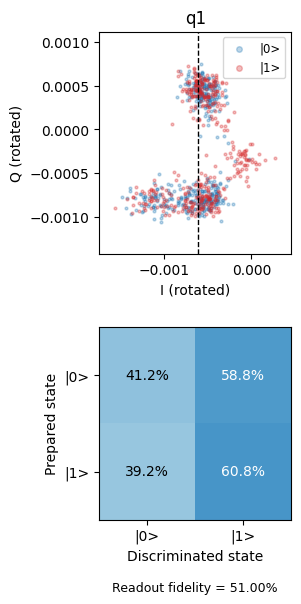

In [14]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [11]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


## Release hardware connection

In [8]:
from qcodes.instrument import Instrument

Instrument.close_all()